# Exploratory Data Analysis (EDA) - Tutor CENEVAL
Este notebook tiene como objetivo explorar y entender la conformación del dataset `dataset_ceneval_super_final.csv` 
para el entrenamiento del modelo de Machine Learning (Random Forest).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones visuales para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carga de Datos
Cargamos el dataset directamente desde la carpeta `data`.

In [2]:
# Ruta relativa al dataset
dataset_path = '../data/dataset_ceneval_super_final.csv'
df = pd.read_csv(dataset_path)

# Mostramos las primeras filas para verificar que se cargó correctamente
display(df.head())

,texto,respuesta,etiqueta,area_origen
0,Imagina que estás programando un dispositivo e...,Una señal enviada a la CPU por un dispositivo ...,1,arquitectura-computadoras_gemma_local
1,"¿Qué es la ""Currificación"" (Currying)?",Técnica funcional que transforma una función q...,2,lenguajes-programacion
2,Que es un atributo de clase?,Variable compartida por todas las instancias d...,2,programacion-objetos
3,"¿Hace unos años, qué protocolo comenzó a apare...",Respuesta: C - La respuesta correcta es WPS (W...,2,MMLU_computer_security
4,Explica por qué no todos los modelos de aprend...,pero la mayoria de modelos comunes si.,3,inteligencia-computacional_gemma_local


## 2. Estructura y Tipos de Datos
Revisamos la información de las columnas y los tipos de datos que pandas ha inferido.

In [3]:
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   texto        2020 non-null   str  
 1   respuesta    2020 non-null   str  
 2   etiqueta     2020 non-null   int64
 3   area_origen  2020 non-null   str  
dtypes: int64(1), str(3)
memory usage: 656.3 KB


## 3. Análisis de Valores Nulos
Es importante asegurarnos de que no haya preguntas o etiquetas vacías antes de entrenar.

In [4]:
print("Valores nulos por columna:")
display(df.isnull().sum())

Valores nulos por columna:


texto          0
respuesta      0
etiqueta       0
area_origen    0
dtype: int64

## 4. Distribución de Etiquetas (Macro-Áreas)
Analizamos cómo están balanceadas las clases (`etiqueta`) en el dataset. 
Según la inspección visual, las etiquetas corresponden a:
* **0:** Algoritmia y Estructuras de Datos
* **1:** Arquitectura de Computadoras y Sistemas
* **2:** Ingeniería de Software, Bases de Datos y Ciberseguridad
* **3:** Computación Inteligente y Sistemas Distribuidos

C:\Users\mario\AppData\Local\Temp\ipykernel_8880\2632687246.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='etiqueta', palette='viridis')


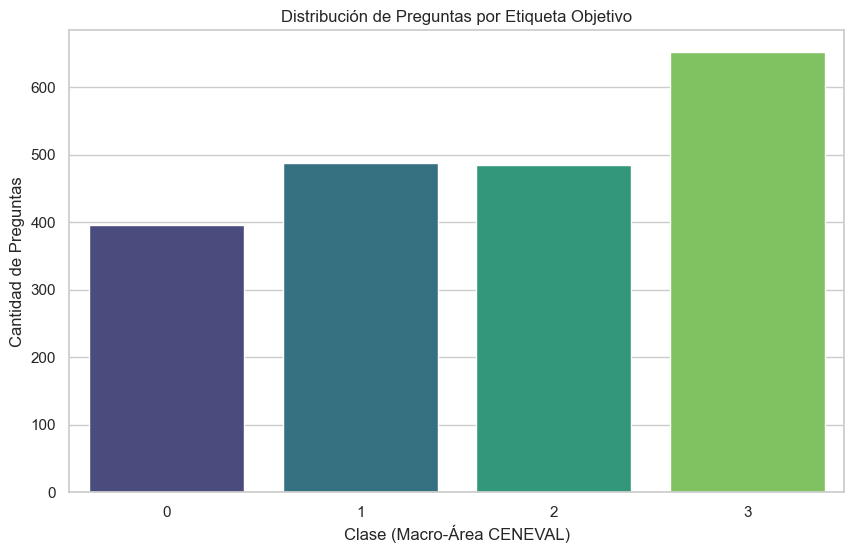

In [5]:
sns.countplot(data=df, x='etiqueta', palette='viridis')
plt.title('Distribución de Preguntas por Etiqueta Objetivo')
plt.xlabel('Clase (Macro-Área CENEVAL)')
plt.ylabel('Cantidad de Preguntas')
plt.show()

## 5. Distribución por Área de Origen
Veamos de qué subtemas o fuentes (ej. datasets generados por Gemma o extraídos de MMLU) provienen los datos.

C:\Users\mario\AppData\Local\Temp\ipykernel_8880\1599157433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='area_origen', order=df['area_origen'].value_counts().index, palette='magma')


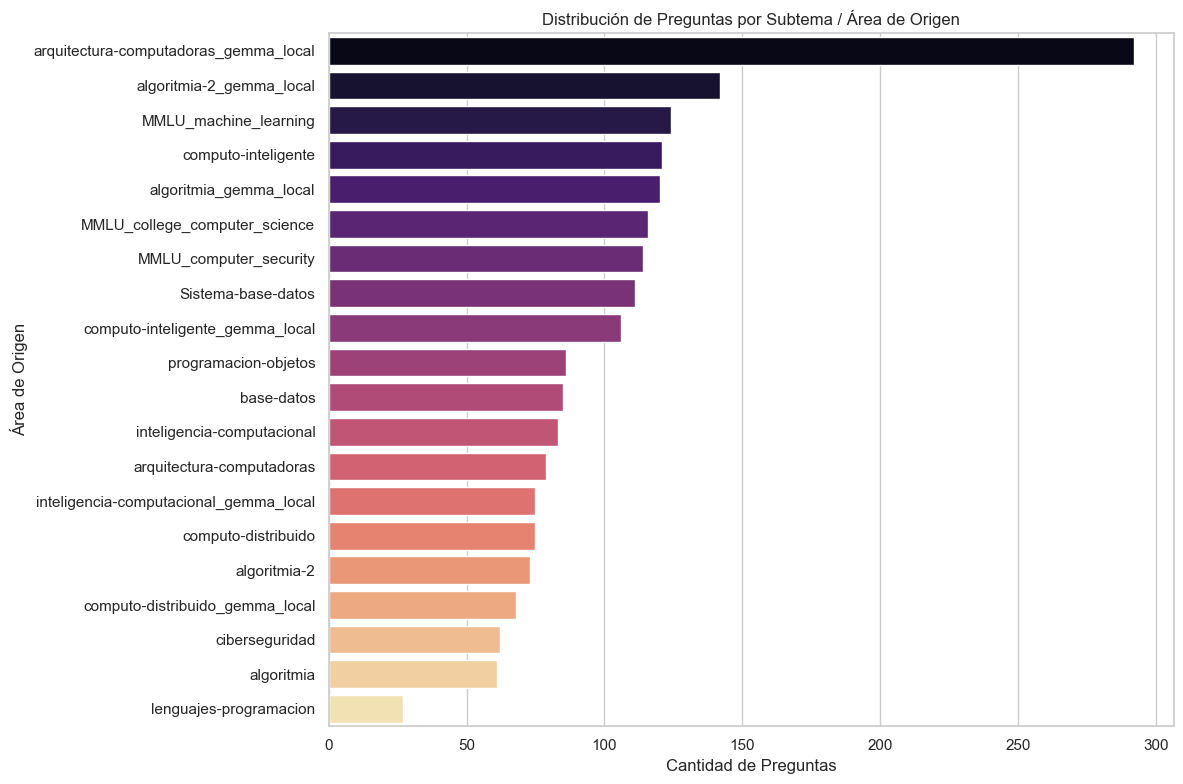

In [6]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='area_origen', order=df['area_origen'].value_counts().index, palette='magma')
plt.title('Distribución de Preguntas por Subtema / Área de Origen')
plt.xlabel('Cantidad de Preguntas')
plt.ylabel('Área de Origen')
plt.tight_layout()
plt.show()

## 6. Conclusiones del EDA
* **Balanceo de Clases:** (Aquí puedes anotar si notas que la clase 2 tiene muchas más preguntas que la 0).
* **Limpieza:** (Anotaciones sobre posibles valores nulos a rellenar o descartar).
* **Próximos Pasos:** Se recomienda aplicar técnicas de NLP (TF-IDF, Bag of Words o Embeddings) sobre las columnas `texto` y `respuesta` antes de pasarlas al modelo Random Forest.